# Principal Component Ananlysis (PCA)

# Import necessary libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
from sklearn.decomposition import PCA #Principal Component Analysis (PCA)
from sklearn.preprocessing import StandardScaler #Data standardization, feature scaling

# Load dataset

In [3]:
maize_data = pd.read_csv('maize_data_PCA.csv')
maize_data.head()

,Genotypes,FT,PH,KRPC,KPR,CL,CW,1000K,SH,KYPP
0,CML-269,74.67,145.4,12.67,16.93,14.11,42.47,200.00,72.58,48.98
1,CML-296,70.67,154.2,12.27,22.40,12.61,21.60,229.67,58.53,40.38
2,CML-298,81.67,182.2,13.07,23.27,12.88,33.87,205.00,80.12,89.24
3,CML-307,69.33,159.2,13.60,24.93,15.29,66.80,220.00,77.53,59.47
4,CML-482,82.67,176.6,13.20,18.47,14.47,47.60,200.00,58.97,43.57


In [5]:
# select the dataframe for PCA
data = maize_data.iloc[:, 1:10]
data.head()

,FT,PH,KRPC,KPR,CL,CW,1000K,SH,KYPP
0,74.67,145.4,12.67,16.93,14.11,42.47,200.00,72.58,48.98
1,70.67,154.2,12.27,22.40,12.61,21.60,229.67,58.53,40.38
2,81.67,182.2,13.07,23.27,12.88,33.87,205.00,80.12,89.24
3,69.33,159.2,13.60,24.93,15.29,66.80,220.00,77.53,59.47
4,82.67,176.6,13.20,18.47,14.47,47.60,200.00,58.97,43.57


In [7]:
# Assign trait labels from dataset
d = maize_data.iloc[:, 0]
columns = ['FT','PH','KRPC','KPR','CL','CW','1000K', 'SH', 'KYPP']

In [9]:
# Create DataFrame
df = pd.DataFrame(data, columns=columns)

# Data preprocessing


In [11]:
# Standardization
scaler = StandardScaler()
Z = scaler.fit_transform(df)

# Covariance & Correlation Matrix: 


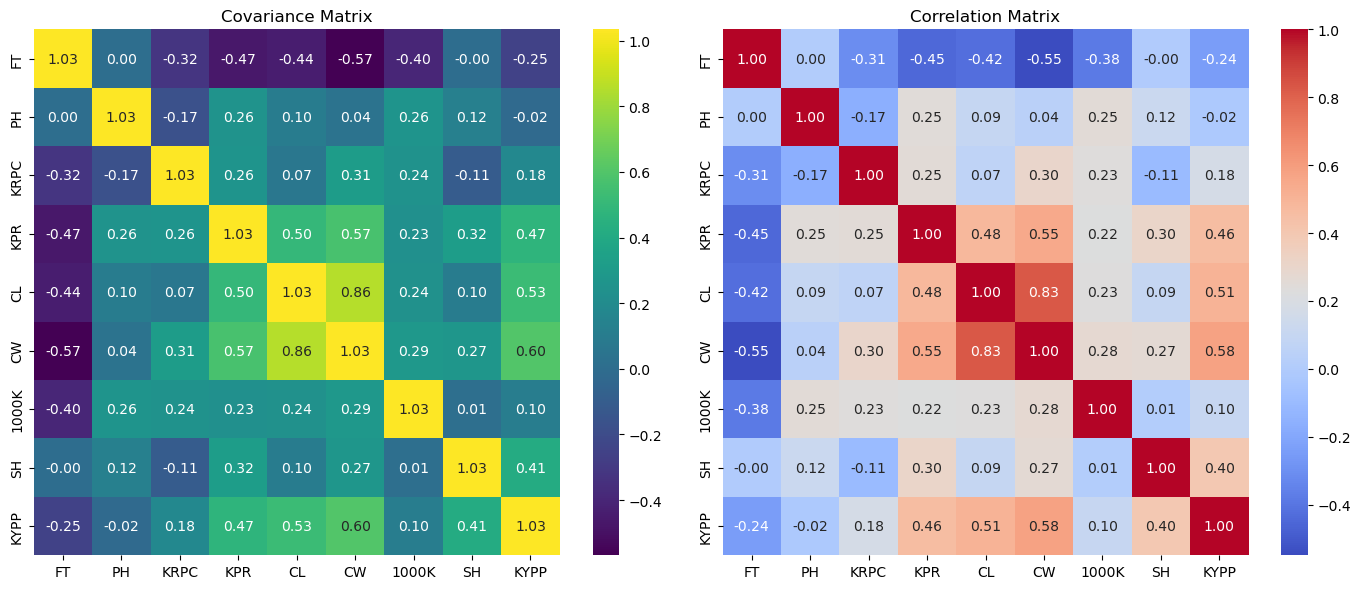

In [13]:
# Compute the Covariance and Correlation matrix
cov_matrix = np.cov(Z.T)
corr_matrix = np.corrcoef(Z.T)

# Plot the Covariance Matrix
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cov_matrix, annot=True, cmap='viridis', fmt='.2f', xticklabels=columns, yticklabels=columns)
plt.title('Covariance Matrix')

# Plot the Correlation Matrix
plt.subplot(1, 2, 2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', xticklabels=columns, yticklabels=columns)
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()


# Eigen Decomposition: 

In [15]:
# Perform PCA based on Covariance matrix
eigenvalues_cov, eigenvectors_cov = np.linalg.eig(cov_matrix)

# Perform PCA based on Correlation matrix
eigenvalues_corr, eigenvectors_corr = np.linalg.eig(corr_matrix)

# Sorting Eigenvalues: 

In [17]:
# Sort eigenvalues in descending order
sorted_idx_cov = np.argsort(eigenvalues_cov)[::-1]
sorted_eigenvalues_cov = eigenvalues_cov[sorted_idx_cov]
sorted_eigenvectors_cov = eigenvectors_cov[:, sorted_idx_cov]

sorted_idx_corr = np.argsort(eigenvalues_corr)[::-1]
sorted_eigenvalues_corr = eigenvalues_corr[sorted_idx_corr]
sorted_eigenvectors_corr = eigenvectors_corr[:, sorted_idx_corr]

# Print Eigenvalues with labels (Covariance)
print("\nEigenvalues (Covariance Matrix):")
for i, val in enumerate(sorted_eigenvalues_cov):
    print(f"PC {i+1}: {val:.4f}")

# Print Eigenvalues with labels (Correlation)
print("\nEigenvalues (Correlation Matrix):")
for i, val in enumerate(sorted_eigenvalues_corr):
    print(f"PC {i+1}: {val:.4f}")


Eigenvalues (Covariance Matrix):
PC 1: 3.5305
PC 2: 1.4403
PC 3: 1.2707
PC 4: 0.9068
PC 5: 0.6789
PC 6: 0.6031
PC 7: 0.4080
PC 8: 0.3653
PC 9: 0.1067

Eigenvalues (Correlation Matrix):
PC 1: 3.4129
PC 2: 1.3923
PC 3: 1.2283
PC 4: 0.8766
PC 5: 0.6563
PC 6: 0.5830
PC 7: 0.3944
PC 8: 0.3531
PC 9: 0.1031


# Eigenvectors for covariance and correlation matrix

In [19]:
# Print Eigenvectors with labels
eigenvectors_cov_df = pd.DataFrame(eigenvectors_cov, index=columns, columns=[f'PC{i+1}' for i in range(len(eigenvectors_cov[0]))])
print("\nEigenvectors (Covariance Matrix):")
print(eigenvectors_cov_df)

eigenvectors_corr_df = pd.DataFrame(eigenvectors_corr, index=columns, columns=[f'PC{i+1}' for i in range(len(eigenvectors_corr[0]))])
print("\nEigenvectors (Correlation Matrix):")
print(eigenvectors_corr_df)


Eigenvectors (Covariance Matrix):
            PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
FT     0.363706  0.346586  0.080368 -0.128742  0.080078 -0.139963  0.678603   
PH    -0.083197  0.291203 -0.744102  0.006669  0.010126 -0.390485  0.164710   
KRPC  -0.198493 -0.528288  0.171101  0.203676  0.560666 -0.334301  0.287316   
KPR   -0.410096  0.110811 -0.101331 -0.079393  0.188083 -0.468342 -0.318650   
CL    -0.431123  0.055477  0.058653  0.617403 -0.544101 -0.012469  0.208309   
CW    -0.487357 -0.001328  0.132335 -0.717006 -0.211632  0.039005  0.100325   
1000K -0.236100 -0.288930 -0.524706 -0.027097  0.184779  0.612811  0.264731   
SH    -0.181511  0.589426  0.091814  0.198888  0.506209  0.341886 -0.227749   
KYPP  -0.375692  0.264061  0.309209 -0.004498  0.111975  0.052246  0.390986   

            PC8       PC9  
FT    -0.472211  0.122782  
PH     0.403684  0.108973  
KRPC   0.117304  0.297218  
KPR   -0.595998 -0.302491  
CL    -0.177800  0.234994  
CW    

# Compute Cumulative Variance Explained:

In [22]:
# Compute cumulative variance explained by each component
cumulative_variance_cov = np.cumsum(sorted_eigenvalues_cov) / np.sum(sorted_eigenvalues_cov)
cumulative_variance_corr = np.cumsum(sorted_eigenvalues_corr) / np.sum(sorted_eigenvalues_corr)

# Combine eigenvalues and variance explained into a DataFrame (Covariance)
pc_labels = [f'PC{i+1}' for i in range(len(sorted_eigenvalues_cov))]
combined_df_cov = pd.DataFrame({
    'Eigenvalue': sorted_eigenvalues_cov,
    'Cumulative Variance Explained (%)': cumulative_variance_cov * 100
}, index=pc_labels)

# Combine eigenvalues and variance explained into a DataFrame (Correlation)
combined_df_corr = pd.DataFrame({
    'Eigenvalue': sorted_eigenvalues_corr,
    'Cumulative Variance Explained (%)': cumulative_variance_corr * 100
}, index=pc_labels)

# Print the combined DataFrame
print("\nCovariance Matrix Eigenvalues and Cumulative Variance:")
print(combined_df_cov)

print("\nCorrelation Matrix Eigenvalues and Cumulative Variance:")
print(combined_df_corr)


Covariance Matrix Eigenvalues and Cumulative Variance:
     Eigenvalue  Cumulative Variance Explained (%)
PC1    3.530548                          37.920698
PC2    1.440342                          53.391036
PC3    1.270676                          67.039034
PC4    0.906777                          76.778489
PC5    0.678890                          84.070273
PC6    0.603142                          90.548466
PC7    0.408025                          94.930956
PC8    0.365274                          98.854269
PC9    0.106671                         100.000000

Correlation Matrix Eigenvalues and Cumulative Variance:
     Eigenvalue  Cumulative Variance Explained (%)
PC1    3.412863                          37.920698
PC2    1.392330                          53.391036
PC3    1.228320                          67.039034
PC4    0.876551                          76.778489
PC5    0.656261                          84.070273
PC6    0.583037                          90.548466
PC7    0.394424     

# Scree Plot: 

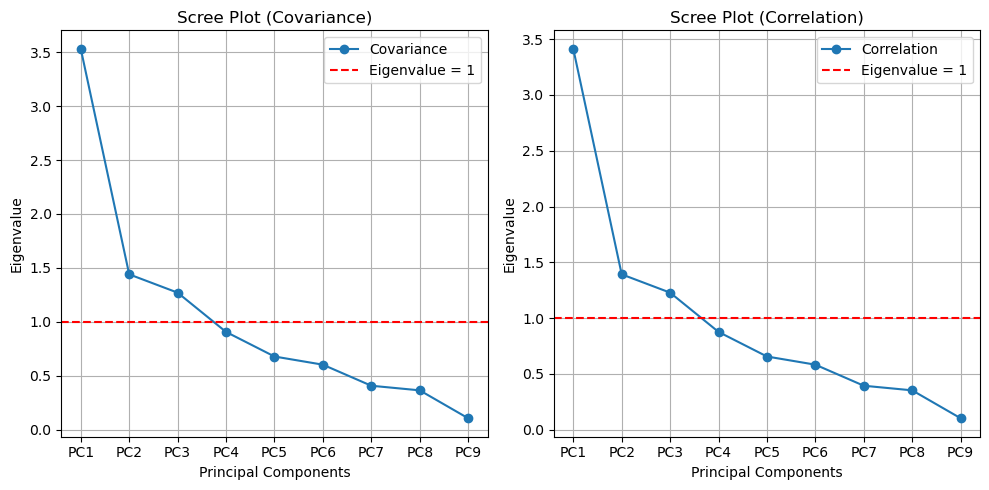

In [24]:
# Scree Plot for Eigenvalues (Covariance and Correlation)
plt.figure(figsize=(10, 5))

# Covariance
plt.subplot(1, 2, 1)
plt.plot(pc_labels, sorted_eigenvalues_cov, 'o-', label='Covariance')
plt.title('Scree Plot (Covariance)')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
plt.legend()
plt.grid(True)

# Correlation
plt.subplot(1, 2, 2)
plt.plot(pc_labels, sorted_eigenvalues_corr, 'o-', label='Correlation')
plt.title('Scree Plot (Correlation)')
plt.xlabel('Principal Components')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# PCA Transformation: 

In [26]:
# Load the dataset and specify the first column as genotypes
maize_data = pd.read_csv('maize_data_PCA.csv')
genotypes = maize_data.iloc[:, 0]  # Extract the genotype column
Z = maize_data.iloc[:, 1:]  # Extract the remaining columns for PCA

# Perform PCA with 3 principal components
pca = PCA(n_components=3)
principal_components = pca.fit_transform(Z)

# Create a DataFrame for the projected data and add genotype labels
pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
pc_df.insert(0, 'Genotype', genotypes.values)  # Insert 'Genotype' as the first column

print(pc_df)


          Genotype        PC1        PC2        PC3
0          CML-269 -15.899443   2.060388   1.224819
1          CML-296 -14.392902 -22.914916  25.271992
2          CML-298  20.079693 -10.719139 -26.537469
3          CML-307  19.463472  -0.364153   7.327802
4          CML-482  -4.500576 -23.942438 -10.788874
5           CM-111 -12.937905 -20.652017 -24.094304
6           CM-135 -32.047135   8.363025   5.745658
7           CM-140  -7.124506  -6.528640 -24.150676
8         CM-212-2 -28.870292  15.199861  -3.616697
9        CM- 500-1 -10.342612   4.480934  41.194930
10        CM-500-2  16.764417  23.899413  31.270486
11           GYL-1  -4.625971  -0.319977  12.203350
12           GYL-2  -1.640652  13.473765  16.333027
13           GYL-4   4.385701   3.081521 -11.663787
14           GYL-5  15.039802 -11.858837  31.278342
15           GYL-6  39.036488  34.144007  14.307524
16           GYL-7 -34.790298  19.204187  15.697356
17           GYL-8  67.537915  70.182764 -30.315084
18          

# Biplot: 

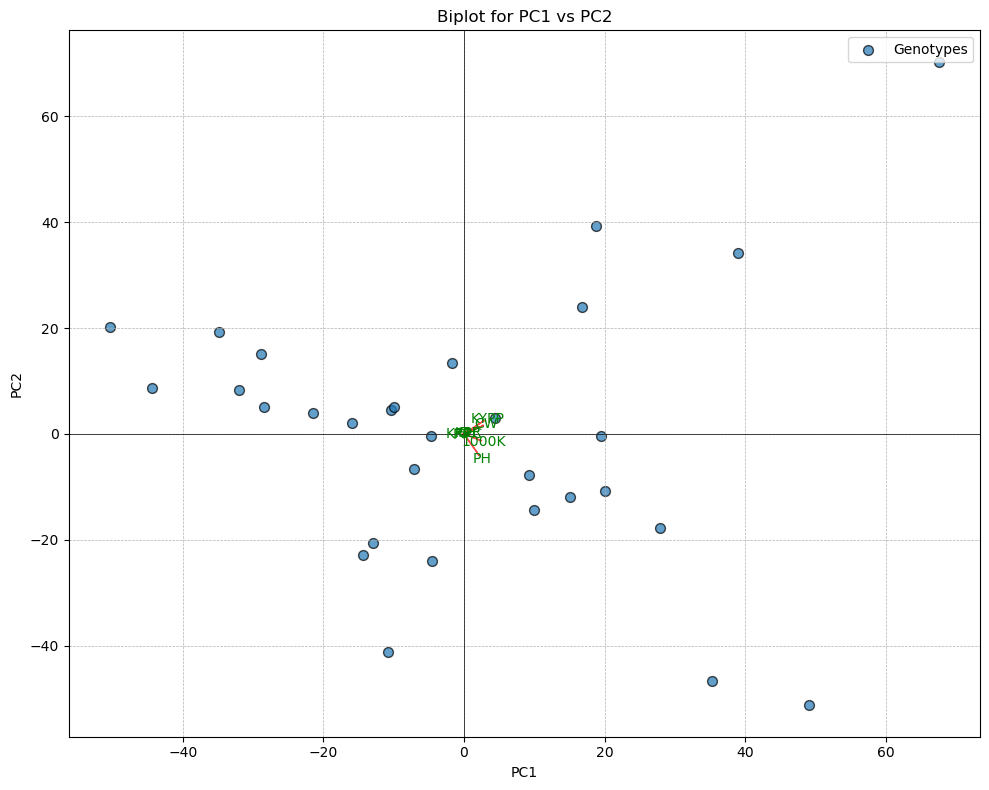

In [28]:
# Biplot for PC1 vs PC2
def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    
    plt.figure(figsize=(10, 8))
    plt.scatter(xs, ys, alpha=0.7, label='Genotypes', edgecolor='k', s=50)

    # Plot column vectors (loadings) for PC1 and PC2
    magnification_factor = 5
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0] * magnification_factor, coeff[i, 1] * magnification_factor,
                  head_width=0.2, head_length=0.2, fc='r', ec='r', alpha=0.7)
        if labels is None:
            plt.text(coeff[i, 0] * magnification_factor * 1.2, coeff[i, 1] * magnification_factor * 1.2,
                     f"Var{i+1}", color='g', ha='center', va='center')
        else:
            plt.text(coeff[i, 0] * magnification_factor * 1.2, coeff[i, 1] * magnification_factor * 1.2,
                     labels[i], color='g', ha='center', va='center')

    plt.title('Biplot for PC1 vs PC2')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    
biplot(principal_components[:, :2], np.transpose(pca.components_[:2, :]), labels=columns)
